Problem Statement

The goal of this project is to predict patient mortality from clinical text data, formulated as a binary classification task where the model determines whether a patient is at risk of death (label = 1) or survival (label = 0). Early identification of high-risk patients is critical in healthcare settings, as it can inform clinical decision-making, resource allocation, and timely interventions.

This task is particularly challenging due to the unstructured nature of clinical text, which often contains domain-specific terminology, abbreviations, and variability in documentation style. Additionally, the dataset exhibits significant class imbalance, with mortality cases representing a minority of the data, making standard accuracy metrics insufficient for evaluation.

To address these challenges, we evaluate both traditional and deep learning approaches for text classification. Specifically, we compare a TF-IDF + Logistic Regression baseline against a fine-tuned BioClinicalBERT model, analyzing their performance under different decision thresholds. Model performance is primarily assessed using the F1 score, which balances precision and recall and is better suited for imbalanced classification problems. We prioritize F1 score over accuracy due to class imbalance (~11% positive class), as accuracy alone would favor predicting the majority class.

Through this analysis, we aim to determine whether more complex contextual models provide meaningful performance improvements over simpler linear approaches, and to better understand the trade-offs between interpretability, performance, and computational complexity in clinical NLP tasks.

Limitations

This study has several limitations. First, as mentioned before, the dataset is imbalanced, which may impact model stability and generalization. Second, TF-IDF ignores word order and contextual relationships, limiting its ability to capture nuanced clinical meaning. Third, while BioClinicalBERT incorporates context, it may require more data or further domain-specific fine-tuning to outperform simpler models. Finally, evaluation is limited to a single dataset, and results may not generalize to other clinical settings.

In [2]:
# ============================================
# CELL 1: imports and configuration (Colab GPU)
# ============================================

import os
import gc
import json
import random
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    auc,
)

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = Path("/content/drive/MyDrive/mimic_project")

ADMISSIONS_FILE = DATA_DIR / "admissions.csv.gz"
ICUSTAYS_FILE = DATA_DIR / "icustays.csv.gz"
RADIOLOGY_FILE = DATA_DIR / "radiology.csv.gz"
DISCHARGE_FILE = DATA_DIR / "discharge.csv.gz"

RESULTS_DIR = Path("/content/drive/MyDrive/mimic_project/results_mimic_icu24_mortality")
RESULTS_DIR.mkdir(exist_ok=True)

HOURS_WINDOW = 24
MIN_TEXT_CHARS = 30
MAX_TFIDF_FEATURES = 20000

TEST_SIZE = 0.20
VAL_SIZE = 0.10

RUN_TRANSFORMER = True
TRANSFORMER_MODEL_NAME = "emilyalsentzer/Bio_ClinicalBERT"
TRANSFORMER_MAX_SAMPLES = 6000
TRANSFORMER_MAX_LEN = 256
TRANSFORMER_EPOCHS = 2
TRANSFORMER_BATCH_SIZE = 16

import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Mounted at /content/drive
CUDA available: True
GPU: NVIDIA A100-SXM4-80GB


In [3]:
# ============================================
# CELL 2: file check and helper functions
# ============================================

for f in [ADMISSIONS_FILE, ICUSTAYS_FILE, RADIOLOGY_FILE]:
    print(f"{f.name}: {'FOUND' if f.exists() else 'MISSING'}")

print(f"{DISCHARGE_FILE.name}: {'FOUND' if DISCHARGE_FILE.exists() else 'MISSING'}")

assert ADMISSIONS_FILE.exists(), f"Missing file: {ADMISSIONS_FILE.name}"
assert ICUSTAYS_FILE.exists(), f"Missing file: {ICUSTAYS_FILE.name}"
assert RADIOLOGY_FILE.exists(), f"Missing file: {RADIOLOGY_FILE.name}"


def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = text.replace("\n", " ").replace("\r", " ").replace("\t", " ")
    text = " ".join(text.split())
    return text.strip()


def save_json(obj, path):
    with open(path, "w") as f:
        json.dump(obj, f, indent=2)


def evaluate_model(y_true, y_pred, y_prob=None, model_name="Model"):
    print(f"\n===== {model_name} =====")
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"F1       : {f1_score(y_true, y_pred, zero_division=0):.4f}")

    if y_prob is not None:
        print(f"ROC AUC  : {roc_auc_score(y_true, y_prob):.4f}")
        print(f"PR AUC   : {average_precision_score(y_true, y_prob):.4f}")

    print("\nClassification report:")
    print(classification_report(y_true, y_pred, digits=4, zero_division=0))


def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()


def summarize_split(df, name):
    print(f"{name}: {df.shape[0]} rows | positive rate = {df['label'].mean():.4f}")

admissions.csv.gz: FOUND
icustays.csv.gz: FOUND
radiology.csv.gz: FOUND
discharge.csv.gz: FOUND


In [4]:
# ============================================
# CELL 3: load admissions + icustays and build ICU cohort
# ============================================

# load required columns only
admissions = pd.read_csv(
    ADMISSIONS_FILE,
    usecols=["subject_id", "hadm_id", "admittime", "dischtime", "hospital_expire_flag"],
    parse_dates=["admittime", "dischtime"]
)

icustays = pd.read_csv(
    ICUSTAYS_FILE,
    usecols=["subject_id", "hadm_id", "stay_id", "intime", "outtime"],
    parse_dates=["intime", "outtime"]
)

# basic cleaning
admissions = admissions.dropna(subset=["hadm_id", "admittime", "hospital_expire_flag"]).copy()
admissions["hadm_id"] = admissions["hadm_id"].astype(int)

# create binary label (in-hospital mortality)
admissions["label"] = admissions["hospital_expire_flag"].astype(int)

icustays = icustays.dropna(subset=["hadm_id", "intime"]).copy()
icustays["hadm_id"] = icustays["hadm_id"].astype(int)

# keep only the earliest ICU stay per admission
icustays_first = (
    icustays.sort_values(["hadm_id", "intime"])
    .drop_duplicates(subset=["hadm_id"], keep="first")
    .copy()
)

# merge ICU stays with admissions
cohort = icustays_first.merge(
    admissions[["hadm_id", "subject_id", "admittime", "dischtime", "label"]],
    on="hadm_id",
    how="inner"
)

print("Admissions:", admissions.shape)
print("ICU stays:", icustays.shape)
print("ICU cohort:", cohort.shape)
print("Mortality rate:", round(cohort["label"].mean(), 4))

cohort.head()

Admissions: (546028, 6)
ICU stays: (94458, 5)
ICU cohort: (85242, 9)
Mortality rate: 0.1112


,subject_id_x,hadm_id,stay_id,intime,outtime,subject_id_y,admittime,dischtime,label
0,14046553,20000094,35605481,2150-03-02 15:19:31,2150-03-03 11:28:38,14046553,2150-03-02 00:00:00,2150-03-03 09:21:00,1
1,14990224,20000147,30503572,2121-08-30 16:33:54,2121-08-31 21:29:49,14990224,2121-08-30 16:33:00,2121-09-03 15:45:00,0
2,17913090,20000351,30593599,2145-06-13 20:10:27,2145-06-14 16:49:38,17913090,2145-06-13 02:09:00,2145-06-18 17:52:00,0
3,16788749,20000808,35191063,2180-01-12 22:07:00,2180-01-13 13:36:47,16788749,2180-01-12 20:59:00,2180-01-25 12:10:00,0
4,15583900,20000916,39464752,2162-08-13 03:26:53,2162-08-13 20:54:23,15583900,2162-08-13 01:57:00,2162-08-18 04:30:00,1


In [5]:
# ============================================
# CELL 4: load radiology notes and keep notes within 24h of ICU intime
# ============================================

# create lookup dictionaries for fast filtering
hadm_to_intime = dict(zip(cohort["hadm_id"], cohort["intime"]))
hadm_to_label = dict(zip(cohort["hadm_id"], cohort["label"]))
valid_hadm_ids = set(cohort["hadm_id"])

# will store all text per admission
radiology_agg = defaultdict(list)

rows_scanned = 0
rows_after_filter = 0
rows_within_window = 0

# read in chunks because file is large
chunk_iter = pd.read_csv(
    RADIOLOGY_FILE,
    usecols=["hadm_id", "charttime", "text"],
    chunksize=100_000
)

for chunk in tqdm(chunk_iter, desc="Processing radiology"):

    rows_scanned += len(chunk)

    # drop missing values
    chunk = chunk.dropna(subset=["hadm_id", "charttime", "text"]).copy()

    # ensure correct types
    chunk["hadm_id"] = pd.to_numeric(chunk["hadm_id"], errors="coerce")
    chunk = chunk.dropna(subset=["hadm_id"])
    chunk["hadm_id"] = chunk["hadm_id"].astype(int)

    # keep only admissions in ICU cohort
    chunk = chunk[chunk["hadm_id"].isin(valid_hadm_ids)].copy()
    rows_after_filter += len(chunk)

    if chunk.empty:
        continue

    # convert timestamps
    chunk["charttime"] = pd.to_datetime(chunk["charttime"], errors="coerce")
    chunk = chunk.dropna(subset=["charttime"])

    # attach ICU intime
    chunk["intime"] = chunk["hadm_id"].map(hadm_to_intime)
    chunk = chunk.dropna(subset=["intime"])

    # compute hours from ICU admission
    chunk["hours_from_icu"] = (
        (chunk["charttime"] - chunk["intime"]).dt.total_seconds() / 3600
    )

    # keep only first 24h
    chunk = chunk[
        (chunk["hours_from_icu"] >= 0) &
        (chunk["hours_from_icu"] <= HOURS_WINDOW)
    ].copy()

    rows_within_window += len(chunk)

    if chunk.empty:
        continue

    # clean text
    chunk["clean_text"] = chunk["text"].map(clean_text)
    chunk = chunk[chunk["clean_text"].str.len() >= MIN_TEXT_CHARS]

    if chunk.empty:
        continue

    # group text by hadm_id
    grouped = chunk.groupby("hadm_id")["clean_text"].apply(list)

    for hadm_id, texts in grouped.items():
        radiology_agg[int(hadm_id)].extend(texts)

    del chunk, grouped
    gc.collect()

# combine into final dataframe
rows = []
for hadm_id, texts in radiology_agg.items():
    doc = " ".join(texts).strip()
    if len(doc) >= MIN_TEXT_CHARS:
        rows.append({
            "hadm_id": hadm_id,
            "text": doc,
            "num_reports_24h": len(texts),
            "label": int(hadm_to_label[hadm_id])
        })

main_df = pd.DataFrame(rows)

print("Rows scanned:", rows_scanned)
print("After cohort filter:", rows_after_filter)
print("Within 24h:", rows_within_window)
print("Final dataset size:", main_df.shape)
print("Final mortality rate:", round(main_df["label"].mean(), 4))

main_df.head()

Processing radiology: 0it [00:00, ?it/s]

Rows scanned: 2321355
After cohort filter: 504963
Within 24h: 93680
Final dataset size: (48290, 4)
Final mortality rate: 0.1154


,hadm_id,text,num_reports_24h,label
0,20001770,EXAMINATION: DX CHEST PORTABLE PICC LINE PLACE...,2,0
1,20003008,EXAMINATION: DX CHEST PORT LINE/TUBE PLCMT 1 E...,1,0
2,20004004,HISTORY: NG tube placement. FINDINGS: In compa...,2,0
3,20028005,HISTORY: Post-procedure intubation with new ox...,2,0
4,20039765,INDICATION: ___ woman with shock. Intubated. A...,2,0


In [6]:
# ============================================
# CELL 5: clean cohort columns and create final text dataset
# ============================================

# keep one subject_id column
if "subject_id_x" in cohort.columns and "subject_id_y" in cohort.columns:
    cohort = cohort.rename(columns={"subject_id_x": "subject_id"})
    cohort = cohort.drop(columns=["subject_id_y"])

# reorder columns for readability
keep_cols = [
    "subject_id", "hadm_id", "stay_id",
    "admittime", "dischtime", "intime", "outtime",
    "label"
]
cohort = cohort[keep_cols].copy()

# save the cohort in case
cohort.to_csv(RESULTS_DIR / "icu_cohort.csv", index=False)

print("Cleaned cohort shape:", cohort.shape)
cohort.head()

Cleaned cohort shape: (85242, 8)


,subject_id,hadm_id,stay_id,admittime,dischtime,intime,outtime,label
0,14046553,20000094,35605481,2150-03-02 00:00:00,2150-03-03 09:21:00,2150-03-02 15:19:31,2150-03-03 11:28:38,1
1,14990224,20000147,30503572,2121-08-30 16:33:00,2121-09-03 15:45:00,2121-08-30 16:33:54,2121-08-31 21:29:49,0
2,17913090,20000351,30593599,2145-06-13 02:09:00,2145-06-18 17:52:00,2145-06-13 20:10:27,2145-06-14 16:49:38,0
3,16788749,20000808,35191063,2180-01-12 20:59:00,2180-01-25 12:10:00,2180-01-12 22:07:00,2180-01-13 13:36:47,0
4,15583900,20000916,39464752,2162-08-13 01:57:00,2162-08-18 04:30:00,2162-08-13 03:26:53,2162-08-13 20:54:23,1


Final dataset shape: (48290, 6)
Mortality rate: 0.1154

Summary statistics:


,num_reports_24h,char_count,word_count
count,48290.000000,48290.000000,48290.000000
mean,1.939884,2020.987616,300.947049
std,1.221045,2063.100581,308.684058
min,1.000000,62.000000,11.000000
25%,1.000000,680.250000,101.000000
50%,2.000000,1298.000000,193.000000
75%,2.000000,2559.000000,380.000000
max,16.000000,28238.000000,4179.000000


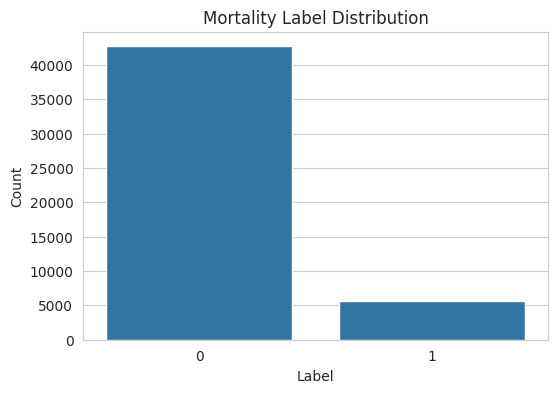

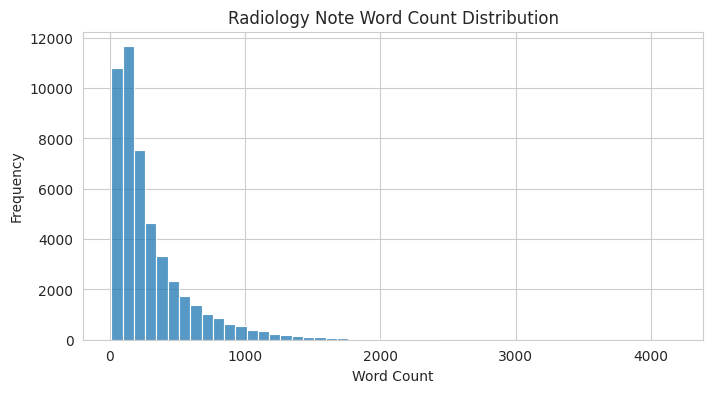

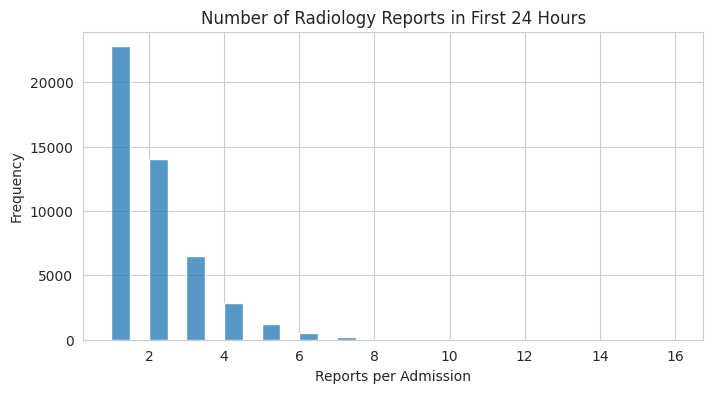

In [7]:
# ============================================
# CELL 6: quick EDA on the final radiology dataset
# ============================================

# basic text length features for analysis
main_df["char_count"] = main_df["text"].str.len()
main_df["word_count"] = main_df["text"].str.split().str.len()

# save the final modeling dataset
main_df.to_csv(RESULTS_DIR / "main_icu24_radiology_dataset.csv", index=False)

print("Final dataset shape:", main_df.shape)
print("Mortality rate:", round(main_df["label"].mean(), 4))
print("\nSummary statistics:")
display(main_df[["num_reports_24h", "char_count", "word_count"]].describe())

# label distribution
plt.figure(figsize=(6, 4))
sns.countplot(x="label", data=main_df)
plt.title("Mortality Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

# word count distribution
plt.figure(figsize=(8, 4))
sns.histplot(main_df["word_count"], bins=50)
plt.title("Radiology Note Word Count Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

# number of reports in first 24h
plt.figure(figsize=(8, 4))
sns.histplot(main_df["num_reports_24h"], bins=30)
plt.title("Number of Radiology Reports in First 24 Hours")
plt.xlabel("Reports per Admission")
plt.ylabel("Frequency")
plt.show()

In [8]:

# ============================================
# CELL 7: train / validation / test split
# ============================================

# split into train and test first
train_df, test_df = train_test_split(
    main_df[["hadm_id", "text", "label"]],
    test_size=TEST_SIZE,
    stratify=main_df["label"],
    random_state=SEED
)

# split train into train + validation
train_df, val_df = train_test_split(
    train_df,
    test_size=VAL_SIZE,
    stratify=train_df["label"],
    random_state=SEED
)

# sanity check
summarize_split(train_df, "Train")
summarize_split(val_df, "Validation")
summarize_split(test_df, "Test")

Train: 34768 rows | positive rate = 0.1154
Validation: 3864 rows | positive rate = 0.1154
Test: 9658 rows | positive rate = 0.1154



===== Majority Baseline =====
Accuracy : 0.8846
Precision: 0.0000
Recall   : 0.0000
F1       : 0.0000

Classification report:
              precision    recall  f1-score   support

           0     0.8846    1.0000    0.9387      8543
           1     0.0000    0.0000    0.0000      1115

    accuracy                         0.8846      9658
   macro avg     0.4423    0.5000    0.4694      9658
weighted avg     0.7824    0.8846    0.8304      9658



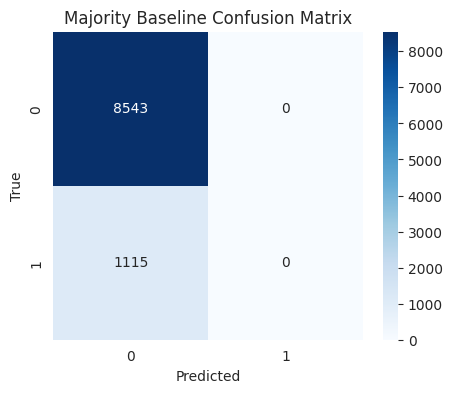

In [9]:
# ============================================
# CELL 8: majority baseline
# ============================================

# dummy classifier that always predicts majority class
dummy = DummyClassifier(strategy="most_frequent")

# dummy input
X_dummy_train = np.zeros((len(train_df), 1))
X_dummy_test = np.zeros((len(test_df), 1))

dummy.fit(X_dummy_train, train_df["label"])

# predictions
dummy_preds = dummy.predict(X_dummy_test)

# evaluate
evaluate_model(
    test_df["label"],
    dummy_preds,
    model_name="Majority Baseline"
)

plot_confusion(
    test_df["label"],
    dummy_preds,
    "Majority Baseline Confusion Matrix"
)

TF-IDF matrix shapes:
X_train: (34768, 20000)
X_val  : (3864, 20000)
X_test : (9658, 20000)

===== TF-IDF + Logistic Regression (Validation) =====
Accuracy : 0.7697
Precision: 0.2798
Recall   : 0.6323
F1       : 0.3879
ROC AUC  : 0.8097
PR AUC   : 0.3730

Classification report:
              precision    recall  f1-score   support

           0     0.9426    0.7876    0.8581      3418
           1     0.2798    0.6323    0.3879       446

    accuracy                         0.7697      3864
   macro avg     0.6112    0.7099    0.6230      3864
weighted avg     0.8661    0.7697    0.8039      3864


===== TF-IDF + Logistic Regression (Test) =====
Accuracy : 0.7803
Precision: 0.2977
Recall   : 0.6646
F1       : 0.4112
ROC AUC  : 0.8118
PR AUC   : 0.3622

Classification report:
              precision    recall  f1-score   support

           0     0.9478    0.7954    0.8649      8543
           1     0.2977    0.6646    0.4112      1115

    accuracy                         0.7803      

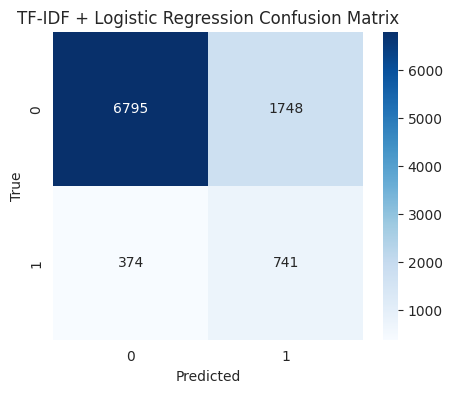

In [10]:
# ============================================
# CELL 9: TF-IDF features and logistic regression baseline
# ============================================

# convert text into sparse bag-of-words / n-gram features
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    max_features=MAX_TFIDF_FEATURES
)

X_train = vectorizer.fit_transform(train_df["text"])
X_val = vectorizer.transform(val_df["text"])
X_test = vectorizer.transform(test_df["text"])

y_train = train_df["label"].values
y_val = val_df["label"].values
y_test = test_df["label"].values

# logistic regression as a strong baseline for text classification
lr = LogisticRegression(
    C=1.0,
    max_iter=2000,
    class_weight="balanced",
    solver="liblinear",
    random_state=SEED
)

lr.fit(X_train, y_train)

# predicted probabilities are used for AUC, PR AUC, and threshold tuning
val_prob = lr.predict_proba(X_val)[:, 1]
test_prob = lr.predict_proba(X_test)[:, 1]

# default threshold = 0.5
val_pred = (val_prob >= 0.5).astype(int)
test_pred = (test_prob >= 0.5).astype(int)

print("TF-IDF matrix shapes:")
print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

evaluate_model(y_val, val_pred, val_prob, model_name="TF-IDF + Logistic Regression (Validation)")
evaluate_model(y_test, test_pred, test_prob, model_name="TF-IDF + Logistic Regression (Test)")

plot_confusion(y_test, test_pred, "TF-IDF + Logistic Regression Confusion Matrix")

Top validation thresholds by F1:


,threshold,precision,recall,f1
0,0.60,0.357247,0.547085,0.432241
1,0.58,0.340108,0.562780,0.423986
2,0.62,0.365260,0.504484,0.423729
3,0.64,0.375221,0.475336,0.419387
4,0.56,0.322864,0.576233,0.413849
5,0.54,0.313953,0.605381,0.413476
6,0.66,0.379377,0.437220,0.406250
7,0.52,0.298056,0.618834,0.402332
8,0.68,0.385776,0.401345,0.393407
9,0.48,0.275349,0.663677,0.389218


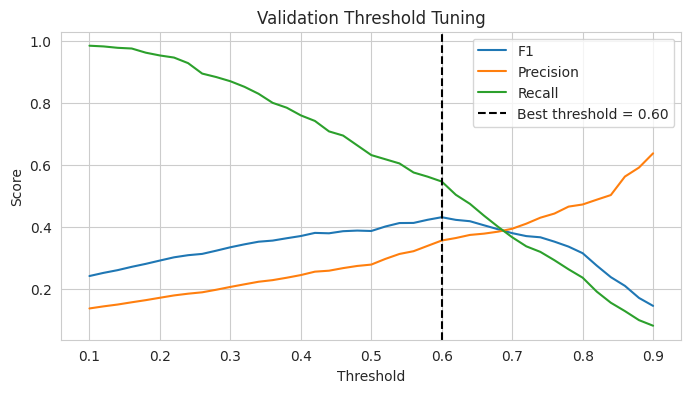


===== TF-IDF + Logistic Regression (Test, tuned threshold = 0.60) =====
Accuracy : 0.8339
Precision: 0.3532
Recall   : 0.5274
F1       : 0.4230
ROC AUC  : 0.8118
PR AUC   : 0.3622

Classification report:
              precision    recall  f1-score   support

           0     0.9341    0.8739    0.9030      8543
           1     0.3532    0.5274    0.4230      1115

    accuracy                         0.8339      9658
   macro avg     0.6436    0.7006    0.6630      9658
weighted avg     0.8670    0.8339    0.8476      9658



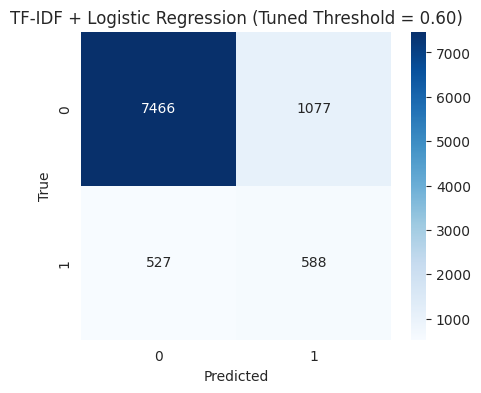

In [11]:
# ============================================
# CELL 10: validation threshold tuning for logistic regression
# ============================================

# search over thresholds because the dataset is imbalanced
thresholds = np.arange(0.10, 0.91, 0.02)

threshold_rows = []
for thr in thresholds:
    pred = (val_prob >= thr).astype(int)

    threshold_rows.append({
        "threshold": thr,
        "precision": precision_score(y_val, pred, zero_division=0),
        "recall": recall_score(y_val, pred, zero_division=0),
        "f1": f1_score(y_val, pred, zero_division=0)
    })

thr_df = pd.DataFrame(threshold_rows).sort_values("f1", ascending=False).reset_index(drop=True)
best_thr = float(thr_df.loc[0, "threshold"])

print("Top validation thresholds by F1:")
display(thr_df.head(10))

plt.figure(figsize=(8, 4))
plt.plot(thresholds, thr_df.sort_values("threshold")["f1"], label="F1")
plt.plot(thresholds, thr_df.sort_values("threshold")["precision"], label="Precision")
plt.plot(thresholds, thr_df.sort_values("threshold")["recall"], label="Recall")
plt.axvline(best_thr, linestyle="--", color="black", label=f"Best threshold = {best_thr:.2f}")
plt.title("Validation Threshold Tuning")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()

# apply best validation threshold to the test set
test_pred_tuned = (test_prob >= best_thr).astype(int)

evaluate_model(
    y_test,
    test_pred_tuned,
    test_prob,
    model_name=f"TF-IDF + Logistic Regression (Test, tuned threshold = {best_thr:.2f})"
)

plot_confusion(
    y_test,
    test_pred_tuned,
    f"TF-IDF + Logistic Regression (Tuned Threshold = {best_thr:.2f})"
)

In [12]:
# ============================================
# CELL 11: inspect top predictive words (interpretability)
# ============================================

# get feature names from TF-IDF
feature_names = np.array(vectorizer.get_feature_names_out())

# get model coefficients
coefs = lr.coef_[0]

# top positive coefficients (predict mortality = 1)
top_pos_idx = np.argsort(coefs)[-20:][::-1]

# top negative coefficients (predict survival = 0)
top_neg_idx = np.argsort(coefs)[:20]

print("Top features predicting mortality (label = 1):")
for i in top_pos_idx:
    print(f"{feature_names[i]:<30} {coefs[i]:.4f}")

print("\nTop features predicting survival (label = 0):")
for i in top_neg_idx:
    print(f"{feature_names[i]:<30} {coefs[i]:.4f}")

Top features predicting mortality (label = 1):
arrest                         6.5824
cardiac arrest                 4.5409
shock                          4.1417
metastatic                     3.9978
ascites                        3.6166
hypotension                    3.5045
diffuse                        3.4985
worsening                      3.4516
aml                            3.2897
bilateral                      3.2449
increased                      2.9211
multiple                       2.8039
extensive                      2.7018
lymphoma                       2.6523
ecmo                           2.5930
failure                        2.5850
iph                            2.5620
metastases                     2.5328
unchanged                      2.5203
left ij                        2.4718

Top features predicting survival (label = 0):
normal                         -2.8301
postoperative                  -2.6600
cabg                           -2.5969
removal                      

Baseline Model: TF-IDF + Logistic Regression

We implemented a baseline model using TF-IDF vectorization with 20,000 features and a Logistic Regression classifier. This approach represents text using term frequency–inverse document frequency weights, capturing the importance of words while ignoring order.

After training, we applied threshold tuning to optimize performance for the imbalanced classification task. The optimal threshold on the validation set was 0.60.

On the test set, the tuned model achieved:
- F1 score: 0.4230
- Precision: 0.3532
- Recall: 0.5274
- ROC AUC: 0.8118
- PR AUC: 0.3622

Threshold tuning improved the balance between precision and recall, increasing overall F1 performance. This demonstrates that even simple linear models can perform strongly when combined with appropriate threshold selection.

Model Interpretability: Feature Analysis

To better understand the behavior of the TF-IDF + Logistic Regression model, we examined the most influential features (words) contributing to predictions for both mortality (label = 1) and survival (label = 0).

For mortality predictions, the model assigns high positive weights to clinically severe and critical terms such as “cardiac arrest,” “shock,” “hypotension,” and “metastatic.” These features are strongly associated with acute or life-threatening conditions, indicating that the model is correctly identifying meaningful clinical signals.

Additionally, terms such as “ecmo,” “failure,” and “ascites” further reflect severe physiological deterioration, while disease-specific terms like “aml” (acute myeloid leukemia) and “lymphoma” align with high-risk patient populations.

For survival predictions, the model assigns negative weights to terms associated with stable or improving conditions, such as “normal,” “mild,” and “trace.” It also highlights procedural and recovery-related terms like “postoperative,” “cabg,” “tavr,” and “tube removed,” which often indicate successful interventions or recovery phases.

Overall, the feature importance analysis demonstrates that the model is learning clinically meaningful patterns. The distinction between acute critical conditions and routine or post-procedural language suggests that the model’s predictions are both interpretable and aligned with domain knowledge.

In [21]:
# ============================================
# CELL 12: prepare full train / validation / test data for transformer
# ============================================

if RUN_TRANSFORMER:
    train_sample = train_df.copy().reset_index(drop=True)
    val_sample = val_df.copy().reset_index(drop=True)
    test_sample = test_df.copy().reset_index(drop=True)

    print("Transformer sample sizes:")
    summarize_split(train_sample, "Train")
    summarize_split(val_sample, "Validation")
    summarize_split(test_sample, "Test")

Transformer sample sizes:
Train: 34768 rows | positive rate = 0.1154
Validation: 3864 rows | positive rate = 0.1154
Test: 9658 rows | positive rate = 0.1154


In [22]:
# ============================================
# CELL 13: tokenize text and build Hugging Face datasets
# ============================================

if RUN_TRANSFORMER:
    import torch
    from datasets import Dataset
    from transformers import AutoTokenizer, DataCollatorWithPadding

    # reset indices so conversion to Dataset is clean
    train_sample = train_sample[["text", "label"]].reset_index(drop=True)
    val_sample = val_sample[["text", "label"]].reset_index(drop=True)
    test_sample = test_sample[["text", "label"]].reset_index(drop=True)

    # convert pandas DataFrames to Hugging Face Dataset objects
    train_ds = Dataset.from_pandas(train_sample)
    val_ds = Dataset.from_pandas(val_sample)
    test_ds = Dataset.from_pandas(test_sample)

    # load tokenizer
    tokenizer = AutoTokenizer.from_pretrained(TRANSFORMER_MODEL_NAME)

    # tokenize text with truncation so long notes do not exceed model limits
    def tokenize_batch(batch):
        return tokenizer(
            batch["text"],
            truncation=True,
            max_length=TRANSFORMER_MAX_LEN
        )

    train_ds = train_ds.map(tokenize_batch, batched=True)
    val_ds = val_ds.map(tokenize_batch, batched=True)
    test_ds = test_ds.map(tokenize_batch, batched=True)

    # keep only the columns needed by the model
    keep_cols = ["input_ids", "attention_mask", "label"]
    train_ds.set_format(type="torch", columns=keep_cols)
    val_ds.set_format(type="torch", columns=keep_cols)
    test_ds.set_format(type="torch", columns=keep_cols)

    # dynamically pad each batch
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    print("Tokenization complete.")
    print("Train dataset size:", len(train_ds))
    print("Validation dataset size:", len(val_ds))
    print("Test dataset size:", len(test_ds))

Map:   0%|          | 0/34768 [00:00<?, ? examples/s]

Map:   0%|          | 0/3864 [00:00<?, ? examples/s]

Map:   0%|          | 0/9658 [00:00<?, ? examples/s]

Tokenization complete.
Train dataset size: 34768
Validation dataset size: 3864
Test dataset size: 9658


In [27]:
# ============================================
# CELL 14: train weighted BioClinicalBERT on full training data
# ============================================

if RUN_TRANSFORMER:
    import numpy as np
    import torch
    from transformers import (
        AutoModelForSequenceClassification,
        TrainingArguments,
        Trainer,
        EarlyStoppingCallback,
    )

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("Device:", device)

    model = AutoModelForSequenceClassification.from_pretrained(
        TRANSFORMER_MODEL_NAME,
        num_labels=2
    )

    train_label_counts = train_sample["label"].value_counts().sort_index()
    n_neg = train_label_counts.get(0, 0)
    n_pos = train_label_counts.get(1, 0)

    class_weights = torch.tensor(
        [1.0, n_neg / max(n_pos, 1)],
        dtype=torch.float
    ).to(device)

    print("Training label counts:", train_label_counts.to_dict())
    print("Class weights:", class_weights.detach().cpu().numpy())

    class WeightedTrainer(Trainer):
        def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
            labels = inputs.pop("labels")
            outputs = model(**inputs)
            logits = outputs.logits

            loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights)
            loss = loss_fct(logits, labels)

            return (loss, outputs) if return_outputs else loss

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        probs = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()
        preds = np.argmax(logits, axis=1)

        return {
            "accuracy": accuracy_score(labels, preds),
            "precision": precision_score(labels, preds, zero_division=0),
            "recall": recall_score(labels, preds, zero_division=0),
            "f1": f1_score(labels, preds, zero_division=0),
            "roc_auc": roc_auc_score(labels, probs),
            "pr_auc": average_precision_score(labels, probs),
        }

    training_args = TrainingArguments(
        output_dir=str(RESULTS_DIR / "bioclinicalbert_fulltrain_ckpt"),
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="steps",
        logging_steps=200,
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        gradient_accumulation_steps=1,
        num_train_epochs=2,
        weight_decay=0.01,
        warmup_ratio=0.10,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        save_total_limit=1,
        fp16=torch.cuda.is_available(),
        report_to="none",
        seed=SEED
    )

    weighted_trainer = WeightedTrainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=1)]
    )

    weighted_trainer.train()

    print("\nValidation results:")
    weighted_val_metrics = weighted_trainer.evaluate(val_ds)
    print(weighted_val_metrics)

    print("\nTest results:")
    weighted_test_metrics = weighted_trainer.evaluate(test_ds)
    print(weighted_test_metrics)

    weighted_test_output = weighted_trainer.predict(test_ds)
    weighted_test_logits = weighted_test_output.predictions
    weighted_test_probs = torch.softmax(torch.tensor(weighted_test_logits), dim=1)[:, 1].numpy()
    weighted_test_true = weighted_test_output.label_ids

Device: cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

Training label counts: {0: 30755, 1: 4013}
Class weights: [1.        7.6638427]


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc,Pr Auc
1,0.580807,0.554461,0.716874,0.241214,0.677130,0.355713,0.785941,0.314887
2,0.487461,0.588309,0.802536,0.304079,0.551570,0.392032,0.794692,0.350137


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Validation results:


{'eval_loss': 0.5883088707923889, 'eval_accuracy': 0.802536231884058, 'eval_precision': 0.30407911001236093, 'eval_recall': 0.5515695067264574, 'eval_f1': 0.39203187250996013, 'eval_roc_auc': 0.7946921730642575, 'eval_pr_auc': 0.3501371011111815, 'eval_runtime': 5.0105, 'eval_samples_per_second': 771.187, 'eval_steps_per_second': 48.299, 'epoch': 2.0}

Test results:
{'eval_loss': 0.5945566892623901, 'eval_accuracy': 0.7996479602402153, 'eval_precision': 0.3015488867376573, 'eval_recall': 0.5587443946188341, 'eval_f1': 0.39170072304306824, 'eval_roc_auc': 0.7889081297514183, 'eval_pr_auc': 0.3443249385606768, 'eval_runtime': 13.8951, 'eval_samples_per_second': 695.063, 'eval_steps_per_second': 43.468, 'epoch': 2.0}


Top validation thresholds for weighted BioClinicalBERT:


,threshold,precision,recall,f1
0,0.62,0.339228,0.473094,0.395131
1,0.64,0.346350,0.457399,0.394203
2,0.60,0.331298,0.486547,0.394187
3,0.56,0.319832,0.513453,0.394148
4,0.58,0.324600,0.500000,0.393645
5,0.52,0.307791,0.540359,0.392189
6,0.50,0.304079,0.551570,0.392032
7,0.54,0.311081,0.522422,0.389958
8,0.48,0.295508,0.560538,0.386997
9,0.40,0.278656,0.632287,0.386831


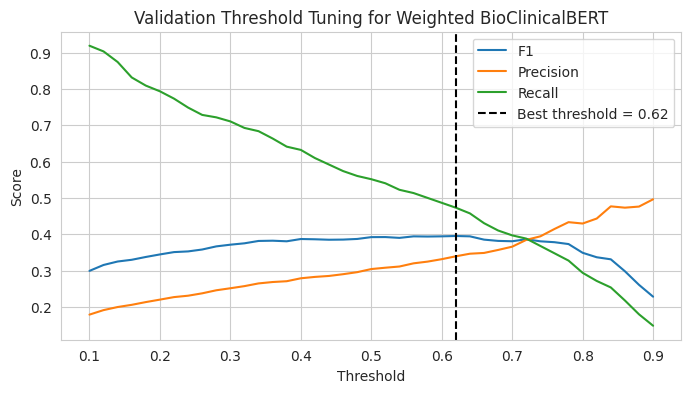


===== Weighted BioClinicalBERT (Test, default threshold = 0.50) =====
Accuracy : 0.7996
Precision: 0.3015
Recall   : 0.5587
F1       : 0.3917
ROC AUC  : 0.7889
PR AUC   : 0.3443

Classification report:
              precision    recall  f1-score   support

           0     0.9352    0.8311    0.8801      8543
           1     0.3015    0.5587    0.3917      1115

    accuracy                         0.7996      9658
   macro avg     0.6184    0.6949    0.6359      9658
weighted avg     0.8620    0.7996    0.8237      9658



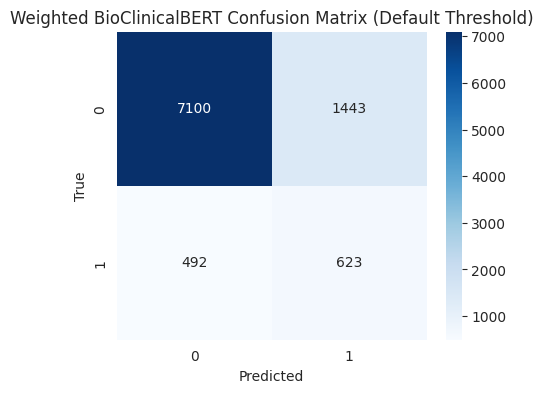


===== Weighted BioClinicalBERT (Test, tuned threshold = 0.62) =====
Accuracy : 0.8298
Precision: 0.3306
Recall   : 0.4628
F1       : 0.3857
ROC AUC  : 0.7889
PR AUC   : 0.3443

Classification report:
              precision    recall  f1-score   support

           0     0.9260    0.8777    0.9012      8543
           1     0.3306    0.4628    0.3857      1115

    accuracy                         0.8298      9658
   macro avg     0.6283    0.6702    0.6434      9658
weighted avg     0.8573    0.8298    0.8417      9658



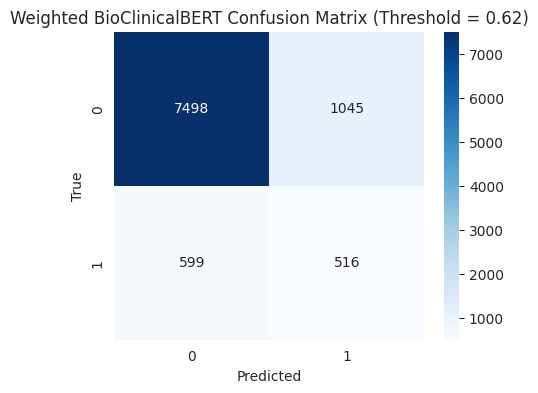

In [28]:
# ============================================
# CELL 15: threshold tuning for weighted BioClinicalBERT
# ============================================

if RUN_TRANSFORMER:
    import numpy as np
    import torch

    # get validation probabilities
    weighted_val_output = weighted_trainer.predict(val_ds)
    weighted_val_logits = weighted_val_output.predictions
    weighted_val_probs = torch.softmax(torch.tensor(weighted_val_logits), dim=1)[:, 1].numpy()
    weighted_val_true = weighted_val_output.label_ids

    thresholds = np.arange(0.10, 0.91, 0.02)

    bert_threshold_rows = []
    for thr in thresholds:
        preds = (weighted_val_probs >= thr).astype(int)

        bert_threshold_rows.append({
            "threshold": thr,
            "precision": precision_score(weighted_val_true, preds, zero_division=0),
            "recall": recall_score(weighted_val_true, preds, zero_division=0),
            "f1": f1_score(weighted_val_true, preds, zero_division=0)
        })

    bert_thr_df = pd.DataFrame(bert_threshold_rows).sort_values("f1", ascending=False).reset_index(drop=True)
    bert_best_thr = float(bert_thr_df.loc[0, "threshold"])

    print("Top validation thresholds for weighted BioClinicalBERT:")
    display(bert_thr_df.head(10))

    plot_df = bert_thr_df.sort_values("threshold")

    plt.figure(figsize=(8, 4))
    plt.plot(plot_df["threshold"], plot_df["f1"], label="F1")
    plt.plot(plot_df["threshold"], plot_df["precision"], label="Precision")
    plt.plot(plot_df["threshold"], plot_df["recall"], label="Recall")
    plt.axvline(bert_best_thr, linestyle="--", color="black", label=f"Best threshold = {bert_best_thr:.2f}")
    plt.title("Validation Threshold Tuning for Weighted BioClinicalBERT")
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.legend()
    plt.show()

    # default threshold predictions
    weighted_test_preds_default = (weighted_test_probs >= 0.5).astype(int)

    evaluate_model(
        weighted_test_true,
        weighted_test_preds_default,
        weighted_test_probs,
        model_name="Weighted BioClinicalBERT (Test, default threshold = 0.50)"
    )

    plot_confusion(
        weighted_test_true,
        weighted_test_preds_default,
        "Weighted BioClinicalBERT Confusion Matrix (Default Threshold)"
    )

    # tuned threshold predictions
    weighted_test_preds_tuned = (weighted_test_probs >= bert_best_thr).astype(int)

    evaluate_model(
        weighted_test_true,
        weighted_test_preds_tuned,
        weighted_test_probs,
        model_name=f"Weighted BioClinicalBERT (Test, tuned threshold = {bert_best_thr:.2f})"
    )

    plot_confusion(
        weighted_test_true,
        weighted_test_preds_tuned,
        f"Weighted BioClinicalBERT Confusion Matrix (Threshold = {bert_best_thr:.2f})"
    )

Transformer Model: Weighted BioClinicalBERT

We fine-tuned a BioClinicalBERT model to capture contextual relationships in clinical text. To address class imbalance (~11% positive class), we incorporated class weighting into the loss function.

The model achieved the following performance on the test set:
- F1 score: 0.3917 (default threshold)
- Precision: 0.3015
- Recall: 0.5587

Threshold tuning identified an optimal threshold of 0.62, but this resulted in a slightly lower F1 score of 0.3857. This indicates that the model was already close to its optimal decision boundary.

While the transformer model improved precision compared to earlier baselines, it did not outperform the TF-IDF model in overall F1 score.

Model Comparison

TF-IDF + Logistic Regression (tuned):
- F1: 0.4230
- Precision: 0.3532
- Recall: 0.5274

Weighted BioClinicalBERT:
- F1: 0.3917
- Precision: 0.3015
- Recall: 0.5587

The TF-IDF model outperformed the transformer model in terms of F1 score and precision, while the transformer achieved slightly higher recall. The superior performance of TF-IDF suggests that the signal in the dataset can be effectively captured through word frequency features without requiring deep contextual modeling.

A key finding is that simpler linear models can outperform transformer-based models when the signal is strongly captured by word frequency features and data size is limited.

Conclusion

In this project, we compared a traditional TF-IDF + Logistic Regression model with a transformer-based BioClinicalBERT model for clinical text classification under class imbalance. While the transformer model captured contextual information and achieved competitive recall, it did not outperform the TF-IDF baseline in overall F1 score.

The TF-IDF model, particularly after threshold tuning, achieved the best performance with an F1 score of 0.4230. This highlights the effectiveness of simpler models when combined with proper calibration techniques such as threshold optimization.

These results suggest that for this dataset, the underlying signal is sufficiently captured by word-level features, and the additional complexity of transformer models does not provide a meaningful advantage. Future work could explore larger datasets or domain-specific pretraining to better leverage transformer architectures.